In [4]:
import os
import sys
sys.path.append(os.path.expanduser("~"))
from camel_dataloader import get_astro_data,get_astro_data_2D_from_3D
from utils import draw_figure,compute_pk, plot_residual, test_plot, InverseCosineLR
sys.path.append('/pscratch/sd/l/lindajin/ICdiffusion/')
from model import BigGANUNet2DModel
import comet_ml
import torch
from torch import nn
from torch.nn.functional import mse_loss, l1_loss
from torch.utils.checkpoint import checkpoint
from torch import autograd, Tensor
from lightning.pytorch import LightningModule, Trainer, seed_everything
from lightning.pytorch.loggers import CometLogger
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from typing import Optional, Tuple
from torch.special import expm1
from tqdm import trange
from torch.distributions.normal import Normal
import numpy as np
import matplotlib.pyplot as plt

torch.set_float32_matmul_precision('highest')
device = torch.device("cuda") if torch.cuda.is_available() else "mps"
print(device)
import importlib
import camel_dataloader
import unet_model
import utils

importlib.reload(utils) 
importlib.reload(camel_dataloader) 
from camel_dataloader import get_astro_data,get_astro_data_2D_from_3D

from utils import draw_figure,InverseCosineLR
from unet_parts import *
import model
importlib.reload(model) 
from model import BigGANUNet2DModel

cuda


In [2]:
seed_everything(42, workers=True)
cropsize = 256
batch_size = 12
num_workers = 8
   
dataset = 'SIMBA'
learning_rate = 1e-3 #1e-4

[rank: 0] Seed set to 42


In [6]:
class trainCNN(LightningModule):
    def __init__(
        self,
        model,
        learning_rate: float = 3.0e-3,
        weight_decay: float = 1.0e-2,
        fourier_upweight_range=(6, 20), 
        fourier_weight=1e-5,
        fourier_loss_scheduler=True,
        draw_figure=None,
        test_plot=None,
        dataset='illustris',
        model_type = 'TF', #'UNet' for residual prediction, 'ResNet' for Mtot
        **kwargs
    ):
        super().__init__()
        self.save_hyperparameters(ignore=["draw_figure","plot_residual"])
        
        self.model= model
        self.dataset=dataset
        print("suite:", self.dataset)
        self.draw_figure=draw_figure
        self.test_plot=test_plot
        self.fourier_upweight_range = fourier_upweight_range
        self.fourier_weight = fourier_weight
        self.fourier_loss_scheduler = fourier_loss_scheduler
        self.model_type = model_type
        
        if self.draw_figure is None:
            def draw_figure(args,**kwargs):
                fig=plt.figure(figsize=(5,5))
                return fig
            self.draw_figure=draw_figure

    def forward(self, cdm_map, params) -> Tensor:
        cdm_map = cdm_map
        params = params
        output = self.model(cdm_map, params) #output kernel should give the invertible Fourier transformation
        return output

    def evaluate(self, batch: Tuple, stage: str = None) -> Tensor:

        cdm_map,params,true_map = batch
        cdm_map = cdm_map.to(device)
        params = params.to(device)
        true_map = true_map.to(device)
        mtot_pred = self(cdm_map,params).to(device)
        fourier_loss = self.fourier_loss(mtot_pred[:,0,:,:].unsqueeze(1), true_map)
        # Log the individual loss components
        self.log("fourier_loss", fourier_loss, on_epoch=True, prog_bar=True)
        loss = l1_loss(mtot_pred[:,0,:,:].unsqueeze(1), true_map)
        self.log("l1_loss", loss, on_epoch=True, prog_bar=True)
        rcc_loss = self.rcc_loss(mtot_pred[:,0,:,:].unsqueeze(1), true_map)
        self.log("l1_100rcc", loss + 100*rcc_loss, on_epoch=True, prog_bar=True)
        EFT_loss = self.EFT_ch_loss(mtot_pred, true_map)
        self.log("EFT_loss", EFT_loss, on_epoch=True, prog_bar=True)
        return loss + 100*rcc_loss

    def weighted_l1_loss(self, batch: Tuple, stage: str = None) -> Tensor:

        cdm_map,params,true_map = batch
        cdm_map = cdm_map.to(device)
        params = params.to(device)
        true_map = true_map.to(device)
        mtot_pred = self(cdm_map,params).to(device)

        return l1_loss(mtot_pred, true_map)

    def get_current_min_max_freq(self):
        if self.trainer is None:
            return self.fourier_upweight_range[0], self.fourier_upweight_range[1]
            
        progress = self.current_epoch / self.trainer.max_epochs
        min_freq = self.fourier_upweight_range[0]
        max_freq = self.fourier_upweight_range[1]
    
        if progress < 0.1:
            return 0.0, 2
        elif progress < 0.3:
            return min_freq / 2, min_freq / 2 + 4
        elif progress < 0.6:
            return min_freq * 3/ 4, min_freq * 3/ 4 + 8
        else:
            return min_freq, max_freq
            
    def EFT_ch_loss(self, output, target):
        '''
        output: [N,2,p,p]
        '''
        if self.model_type != 'EFT':
            return 0    
        target_fft = torch.fft.fft2(target)
        output_fft = torch.fft.fft2(output[:,0,:,:].unsqueeze(1))
        
        _, C, H, W = target.shape
        L = 25. #Mpc/c
        kx = torch.fft.fftfreq(H, d=1. / (H * 2 * np.pi / L)).to(target.device)
        ky = torch.fft.fftfreq(W, d=1. / (W * 2 * np.pi / L)).to(target.device)
        kx, ky = torch.meshgrid(kx, ky, indexing="ij") #[256, 256],[256, 256]
        k = torch.sqrt(kx**2 + ky**2) 

        cross_correlation_fft = target_fft * torch.conj(output_fft)
        # Inverse FFT to get spatial cross-correlation
        cross_correlation = torch.fft.ifft2(cross_correlation_fft).real
        # Normalize cross-correlation coefficient
        norm1 = torch.sqrt(torch.sum(target_fft**2))
        norm2 = torch.sqrt(torch.sum(output_fft**2))
        rcc = cross_correlation / (norm1 * norm2)

        a = torch.randn(1,device = target.device) * self.fourier_weight
        
        term_c = torch.fft.ifft2(output_fft * a * k**2)
        term_J = torch.fft.ifft2(target_fft * (1-rcc**2)**0.5)

        return l1_loss(output[:,1,:,:].unsqueeze(1), term_c.real + term_J.real)


    def rcc_loss(self, output, target):
        target_fft = torch.fft.fft2(target)
        output_fft = torch.fft.fft2(output)

        cross_correlation_fft = target_fft * torch.conj(output_fft)
        cross_correlation_fft.flat[0]=0
        # Normalize cross-correlation coefficient
        norm1 = torch.sqrt(torch.sum(target_fft**2))
        norm2 = torch.sqrt(torch.sum(output_fft**2))
        rcc = cross_correlation_fft / (norm1 * norm2)

        return torch.mean(1-rcc.real**2)
    
    def fourier_loss(self, output, target):
        ## Low pass only
        if self.fourier_loss_scheduler:
            low, high = self.get_current_min_max_freq() 
        else:
            high = self.fourier_upweight_range[1]
            low = self.fourier_upweight_range[0] 

        a = torch.randn(1,device = target.device) * self.fourier_weight
        
        output_filtered_real, output_filtered_img  = self.fourier_filter_EFT(output,low,high,a)
        target_filtered_real, target_filtered_img = self.fourier_filter_EFT(target,low,high,a)
        # kcc, rcc = compute_pk(output_filtered_real.cpu().detach().numpy(),target_filtered_real.cpu().detach().numpy())
        # 100*torch.mean(1 - Tensor(rcc)**2)
        
        loss = torch.mean((output_filtered_real - target_filtered_real) ** 2) + torch.mean((output_filtered_img - target_filtered_img) ** 2) #r_cc is phase not mag
        return loss

    def fourier_filter_EFT(self, target, low=3, high=7, a = -0.001 ):
        target_fft = torch.fft.fft2(target)

        _, C, H, W = target.shape
        L = 25. #Mpc/c
        kx = torch.fft.fftfreq(H, d=1. / (H * 2 * np.pi / L)).to(target.device)
        ky = torch.fft.fftfreq(W, d=1. / (W * 2 * np.pi / L)).to(target.device)
        kx, ky = torch.meshgrid(kx, ky, indexing="ij") #[256, 256],[256, 256]
        k = torch.sqrt(kx**2 + ky**2) 

        order = 2 #2
        low_pass = 1 / (1 + (k / high)**(2 * order))
        high_pass = 1 / (1 + (low / k)**(2 * order))
    
        epsilon = 1e-10  # Small value to avoid division by zero
        if low == 0:
            weight_mask = low_pass / torch.clamp(sum(low_pass), min=epsilon) + 1e-3
        else:
            weight_mask = low_pass*high_pass / torch.clamp(sum(low_pass*high_pass), min=epsilon)  + 1e-3
    

        # Expand the mask for all batches and channels
        weight_mask = weight_mask[None, :, :].to(target.device)

        filtered_target = torch.fft.ifft2(weight_mask * target_fft)
        delta = torch.fft.fft2(filtered_target.real)

        cross_correlation_fft = target_fft * torch.conj(delta)
        # Inverse FFT to get spatial cross-correlation
        cross_correlation = torch.fft.ifft2(cross_correlation_fft).real
        # Normalize cross-correlation coefficient
        norm1 = torch.sqrt(torch.sum(target_fft**2))
        norm2 = torch.sqrt(torch.sum(delta**2))
        rcc = cross_correlation / (norm1 * norm2)

        term_c = torch.fft.ifft2(delta* a * k**2)
        term_J = torch.fft.ifft2(target_fft * (1-rcc**2)**0.5)
        
        return filtered_target.real + term_c.real + term_J.real, filtered_target.imag + term_c.imag + term_J.imag

    def rcc_mean(self,batch):
        cdm_map,params,true_map = batch
        cdm_map = cdm_map.to(device)
        params = params.to(device)
        if self.model_type == 'UNet':
            target_mtot = true_map.to(device) + cdm_map
            pred_mtot = self(cdm_map,params).to(device) + cdm_map
        else:
            target_mtot = true_map.to(device)[:,0,:,:].unsqueeze(1) 
            pred_mtot = self(cdm_map,params).to(device)[:,0,:,:].unsqueeze(1) 
        kcc, P = compute_pk(target_mtot.cpu().detach().numpy(), pred_mtot.cpu().detach().numpy())
        return P.mean()
        

    def training_step(
        self,
        batch: Tuple,
        batch_idx: int,
    ) -> Tensor:
        loss = self.evaluate(batch, "train")
        self.log("train_loss", loss, on_epoch=True)
        log_loss = torch.log(loss)
        return log_loss


    def validation_step(self, batch: Tuple, batch_idx: int) -> Tensor:
        """validate model

        Args:
            batch (Tuple): batch of examples
            batch_idx (int): idx for batch

        Returns:
            Tensor: loss
        """
        conditioning,params,x = batch 
        loss = 0   
        
        if batch_idx == 0:
            sample = self(conditioning,params)
            loss = self.evaluate(batch)
            self.log("val_loss", loss, on_epoch=True, prog_bar=True)
            l1 = self.weighted_l1_loss(batch)
            rcc = self.rcc_mean(batch)
            self.log("val_l1_loss", l1, on_epoch=True, prog_bar=True)
            self.log("val_rcc", rcc, on_epoch=True, prog_bar=True)
            fig = self.draw_figure(x,sample,conditioning,self.dataset,model=self.model_type)            
            if self.logger is not None:
                self.logger.experiment.log_figure(figure=fig)
          
            plt.close()
        return loss

    def test_step(self, batch, batch_idx):
        
        conditioning, params, x = batch    
        loss = 0    
        
        if batch_idx == 0:
            sample = self(conditioning,params)
            fig = self.draw_figure(x,sample,conditioning,self.dataset,model=self.model_type)
            fig_test = self.test_plot(x,sample,conditioning,self.dataset,model=self.model_type)
            self.log_dict({'test_loss': loss}, on_epoch=True)
            if self.logger is not None:
                self.logger.experiment.log_figure(figure=fig)
                self.logger.experiment.log_figure(figure=fig_test)

                loss = self.weighted_l1_loss(batch)
                self.logger.log_metrics({"test_l1_loss": loss.mean()})
                rcc = self.rcc_mean(batch)
                self.log("test_rcc", rcc, on_epoch=True, prog_bar=True)
            plt.show()
        return self.evaluate(batch, "test")
 
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.learning_rate,
            weight_decay=self.hparams.weight_decay,
        )
        warmup_steps = int(self.trainer.max_steps * 0.3)
        '''
        scheduler =torch.optim.lr_scheduler.LinearLR(
                    optimizer, 
                    start_factor=0.1, 
                    end_factor=1.0, 
                    total_iters=warmup_steps
                )
        '''
        if self.fourier_loss_scheduler:
            T_0 = self.trainer.max_epochs 
        else: 
            T_0=2
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[
                # Linear warmup
                
                torch.optim.lr_scheduler.LinearLR(
                    optimizer, 
                    start_factor=0.1, 
                    end_factor=1.0, 
                    total_iters=warmup_steps
                ),
                
                # Cosine Annealing with Warm Restarts
                #torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                #   optimizer, 
                #   T_0=T_0,           # Initial restart period
                #   T_mult=2,     # Multiplicative factor for restart periods
                #   eta_min=1e-6    # Minimum learning rate
                #),

                InverseCosineLR(
                optimizer,
                T_0=T_0,             # Initial restart period
                T_mult=2,            # Multiplicative factor for restart periods
                eta_min=self.hparams.learning_rate,  # Start with the base learning rate
                eta_max=self.hparams.learning_rate * 10  # Increase to 10x the base learning rate
            )

            ],
            milestones=[warmup_steps]
        )
        
        return {'optimizer': optimizer, 'lr_scheduler': scheduler}
    
    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        cdm_map,params,true_map = batch
        return self(cdm_map,params)

In [ ]:
sys.path.append('/pscratch/sd/l/lindajin/Pytorch-UNet/unet')
from unet_model import UNetFiLM,ResNetFiLM,UNetFiLMNoSkip
cnn = trainCNN(
        model =BigGANUNet2DModel(1,1, bilinear = False, use_fourier_features = True, attention = True), #.to(device) #SimpleNet() #ResnetGenerator(1,1) #SimpleNet()
        dataset=dataset,
        learning_rate = 3.0e-5,
        image_shape=(1,cropsize,cropsize),
        fourier_weight=1e-2,
        draw_figure=draw_figure,
        test_plot=test_plot,
        fourier_loss_scheduler=False,
        model_type = 'ResNet',
    ).to(device)

    # Checkpoint every time val_loss improves
val_rcc_checkpoint = ModelCheckpoint(
        filename="best_rcc_model-{epoch}-{step}",
        monitor="val_rcc",
        save_top_k=1, # save only the best ckpt
        mode="max",
        verbose=True,        
    )

val_l1_checkpoint = ModelCheckpoint(
        filename="best_l1_model-{epoch}-{step}",
        monitor="val_l1_loss",
        save_top_k=1, # save only the best ckpt
        mode="min",
        verbose=True,        
    )
    # Checkpoint at every 6000 steps
latest_checkpoint = ModelCheckpoint(
        filename="latest-{epoch}-{step}",
        monitor="step",
        mode="max",
        every_n_train_steps=50, # 50 6000
        save_top_k=10
    )

comet_logger = CometLogger(
            api_key=os.environ.get("COMET_API_KEY"),
            project_name="SIMBA",
            experiment_name='SIMBA_BigGANUNet2DModel_lr_tuning_warmup0.3_increasing_lrp2_epoch20_L1_DEBUG_rcc_6_20_lr_3e4_adamw_1e2_25_thickness_Nbody_Rescalr',
            offline=False,
            save_dir='/pscratch/sd/l/lindajin/LOGS/',
            experiment_key='3ea041bdc3bc47f6b07433b73b274868'
    
)

trainer = Trainer(
        logger=comet_logger,
        accelerator="auto",
        max_epochs=20, #10 1000
        gradient_clip_val=0.5,
        callbacks=[LearningRateMonitor(),
                    latest_checkpoint,
                    val_rcc_checkpoint,
                    val_l1_checkpoint
                  ],
        devices=[1]
    )

In [5]:
dm_25_thick_mtot = get_astro_data_2D_from_3D(
        dataset,
        25,
        num_workers=num_workers,
        batch_size=batch_size,
    )

In [9]:
trainer.fit(model=cnn, datamodule=dm_25_thick_mtot)#,ckpt_path='/pscratch/sd/l/lindajin/LOGS/SIMBA/3ea041bdc3bc47f6b07433b73b274868/checkpoints/latest-epoch=19-step=3500.ckpt')

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/simba/3ea041bdc3bc47f6b07433b73b274868

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name  | Type              | Params | Mode
---------------------------------------------------
0 | model | BigGANUNet2DModel | 27.2 M | eval
---------------------------------------------------
27.2 M    Trainable params
0         Non-trainable params
27.2 M    Total params
108.999   Total estimated model params size (MB)
0         Modules in train mode
382       Modules in eval mode
COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'BigGANUNet2DModel(
  (fourier_features): FourierFeatures()
  (act): Si

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml ExistingExperiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : SIMBA_BigGANUNet2DModel_lr_tuning_warmup0.3_increasing_lrp2_epoch20_L1_DEBUG_rcc_6_20_lr_3e4_adamw_1e2_25_thickness_Nbody_Rescalr
COMET INFO:     url                   : https://www.comet.com/klinjin/simba/3ea041bdc3bc47f6b07433b73b274868
COMET INFO:   Others:
COMET INFO:     Created from : pytorch-lightning
COMET INFO:     Name         : SIMBA_BigGANUNet2DModel_lr_tuning_warmup0.3_increasing_lrp2_epoch20_L1_DEBUG_rcc_6_20_lr_3e4_adamw_1e2_25_thickness_Nbody_Rescalr
COMET INFO:   Parameters:
COMET INFO:     dataset                : SIMBA
COMET INFO:     fourier_loss_scheduler : False
COMET INFO:     fourier_upweight_range : (6, 20)
COMET INFO

RuntimeError: Given groups=1, weight of size [32, 9, 3, 3], expected input[12, 18, 256, 256] to have 9 channels, but got 18 channels instead

In [10]:
path_rcc = val_rcc_checkpoint.best_model_path 
print(path_rcc)
path_l1 = val_l1_checkpoint.best_model_path 
print(path_l1)

/pscratch/sd/l/lindajin/LOGS/SIMBA/3ea041bdc3bc47f6b07433b73b274868/checkpoints/best_rcc_model-epoch=9-step=1750.ckpt
/pscratch/sd/l/lindajin/LOGS/SIMBA/3ea041bdc3bc47f6b07433b73b274868/checkpoints/best_l1_model-epoch=15-step=2800.ckpt


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/simba/3ea041bdc3bc47f6b07433b73b274868

Restoring states from the checkpoint path at /pscratch/sd/l/lindajin/LOGS/SIMBA/3ea041bdc3bc47f6b07433b73b274868/checkpoints/best_rcc_model-epoch=9-step=1750.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'BigGANUNet2DModel(
  (fourier_features): FourierFeatures()
  (act): SiLU()
  (all_modules): ModuleList(
    (0): Conv2d(9, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1-3): 3 x ResnetBlockBigGANpp(
      (GroupNorm_0): GroupNorm(8, 32, eps=1e-06, affine=True)
      (Conv_0): Conv2

CHNG: m_tot         | 0/? [00:00<?, ?it/s]
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot

CHNG: m_totCHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_totCHNG: m_tot
CHNG: m_tot

CHNG: m_t

/global/homes/l/lindajin/utils.py:459: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.flat[0].legend()
/global/homes/l/lindajin/utils.py:492: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.flat[2].legend()
/global/homes/l/lindajin/utils.py:503: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.flat[3].legend()
/tmp/ipykernel_715277/2723435923.py:67: UserWarning: Using a target size (torch.Size([100, 1, 256, 256])) that is different to the input size (torch.Size([100, 2, 256, 256])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return l1_loss(mtot_pred, 


Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.01
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.01
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time t

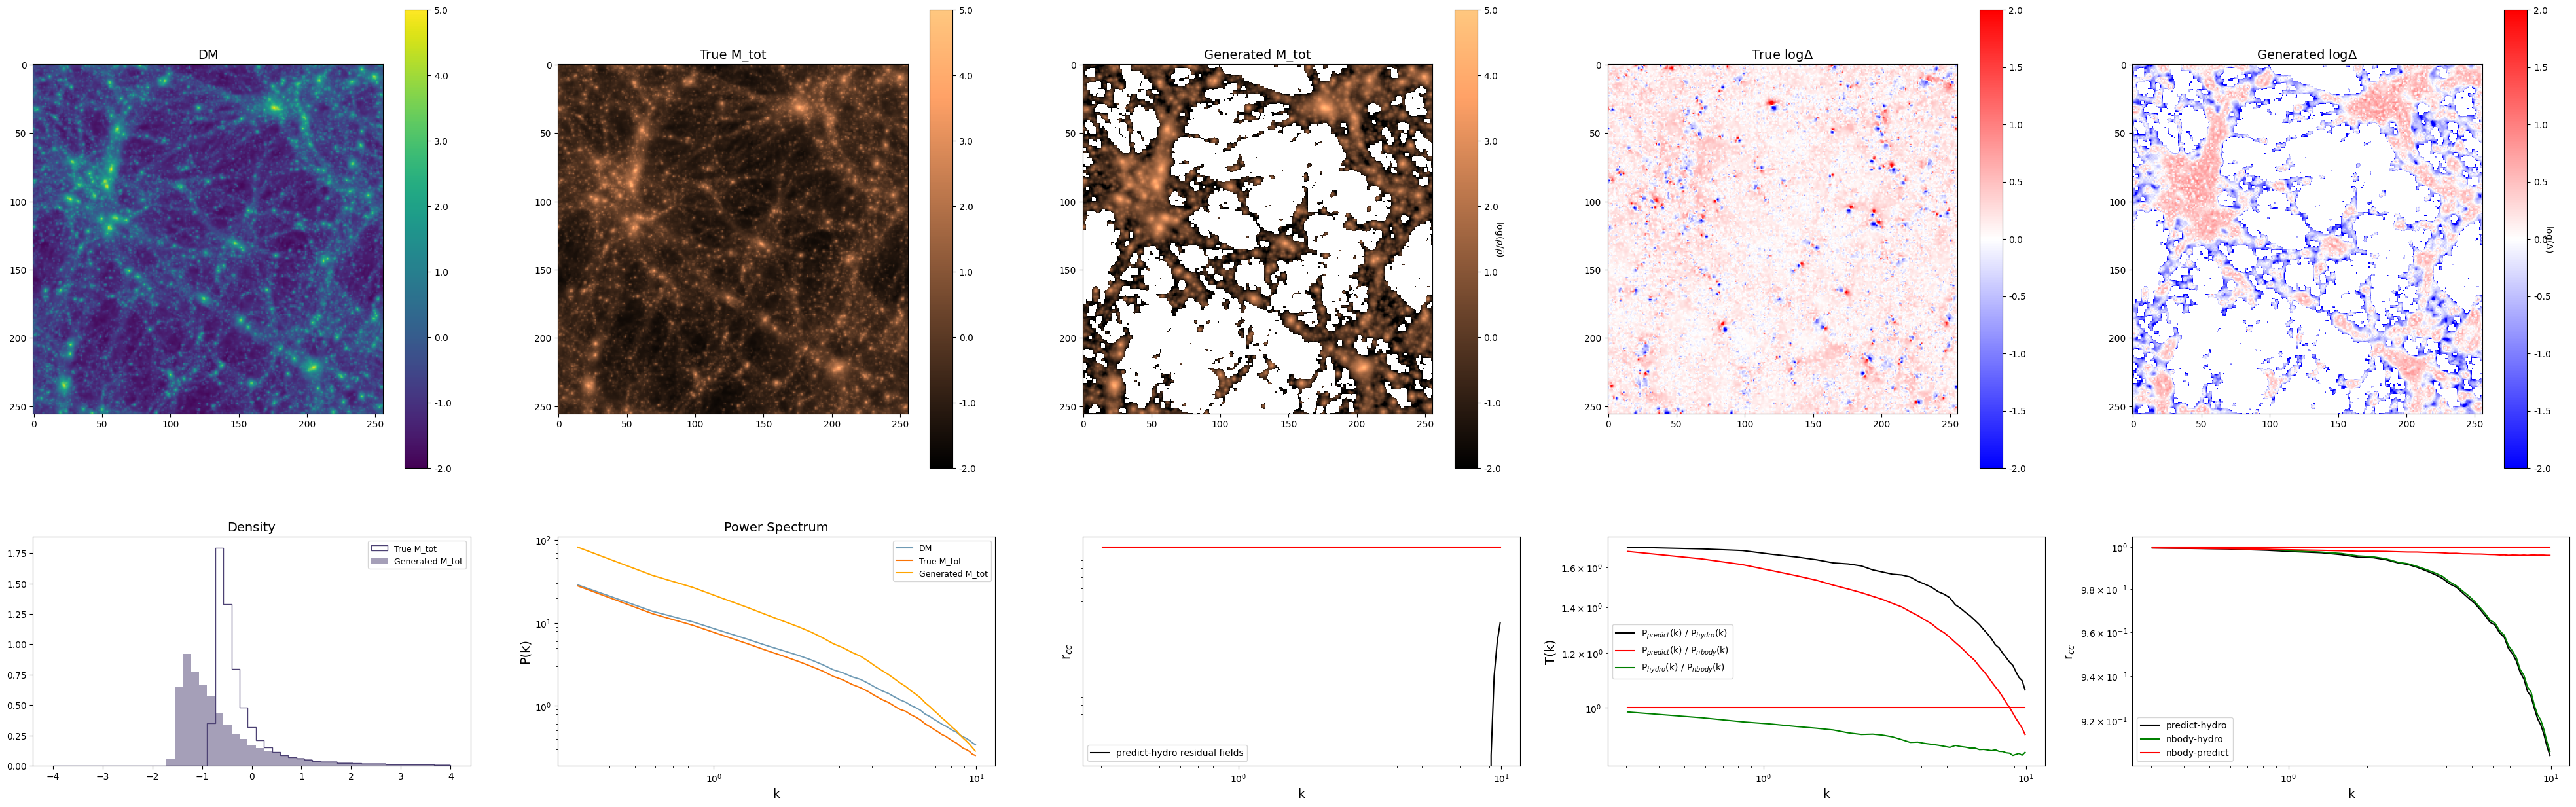

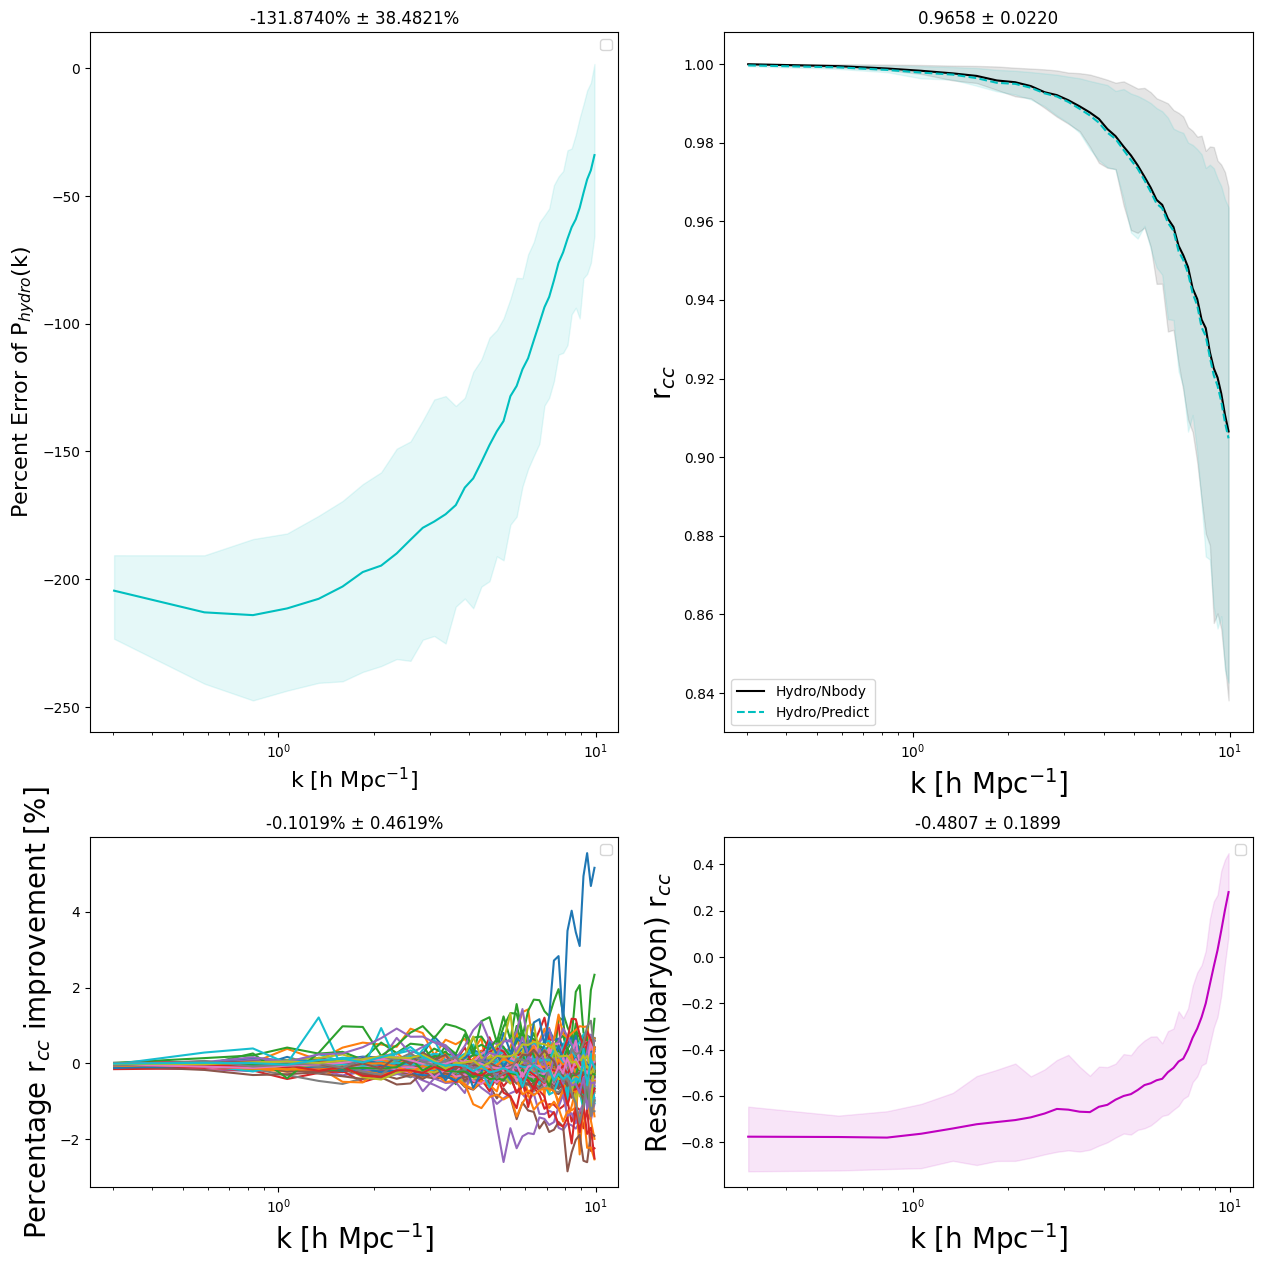

Testing DataLoader 0: 100%|██████████| 3/3 [00:33<00:00,  0.09it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         EFT_loss          │    0.26380066066389385    │
│       fourier_loss        │     4.48032177600584      │
│         l1_100rcc         │    100.29359740144119     │
│          l1_loss          │    0.29359740191452627    │
│         test_loss         │            0.0            │
│         test_rcc          │    0.9641716480255127     │
└───────────────────────────┴───────────────────────────┘

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml ExistingExperiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : SIMBA_BigGANUNet2DModel_lr_tuning_warmup0.3_increasing_lrp2_epoch20_L1_EFT_loss_longer_6_20_lr_3e4_adamw_1e2_25_thickness_Nbody
COMET INFO:     url                   : https://www.comet.com/klinjin/simba/3ea041bdc3bc47f6b07433b73b274868
COMET INFO:   Metrics:
COMET INFO:     EFT_loss     : 0.26380066066389385
COMET INFO:     fourier_loss : 4.48032177600584
COMET INFO:     l1_100rcc    : 100.29359740144119
COMET INFO:     l1_loss      : 0.29359740191452627
COMET INFO:     test_l1_loss : 0.2737581416849258
COMET INFO:     test_loss    : 0.0
COMET INFO:     test_rcc     : 0.9641716480255127
COMET INFO:   Others:
COMET INFO:     Created from : py

In [11]:
test_loss = trainer.test(model=None, datamodule=dm_25_thick_mtot, ckpt_path = path_rcc)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/simba/3ea041bdc3bc47f6b07433b73b274868

Restoring states from the checkpoint path at /pscratch/sd/l/lindajin/LOGS/SIMBA/3ea041bdc3bc47f6b07433b73b274868/checkpoints/best_l1_model-epoch=15-step=2800.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'BigGANUNet2DModel(
  (fourier_features): FourierFeatures()
  (act): SiLU()
  (all_modules): ModuleList(
    (0): Conv2d(9, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1-3): 3 x ResnetBlockBigGANpp(
      (GroupNorm_0): GroupNorm(8, 32, eps=1e-06, affine=True)
      (Conv_0): Conv2

Testing: |          | 0/? [00:00<?, ?it/s]
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot
CHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_t

/tmp/ipykernel_715277/2723435923.py:67: UserWarning: Using a target size (torch.Size([100, 1, 256, 256])) that is different to the input size (torch.Size([100, 2, 256, 256])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return l1_loss(mtot_pred, true_map)



Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.01
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.01
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time t

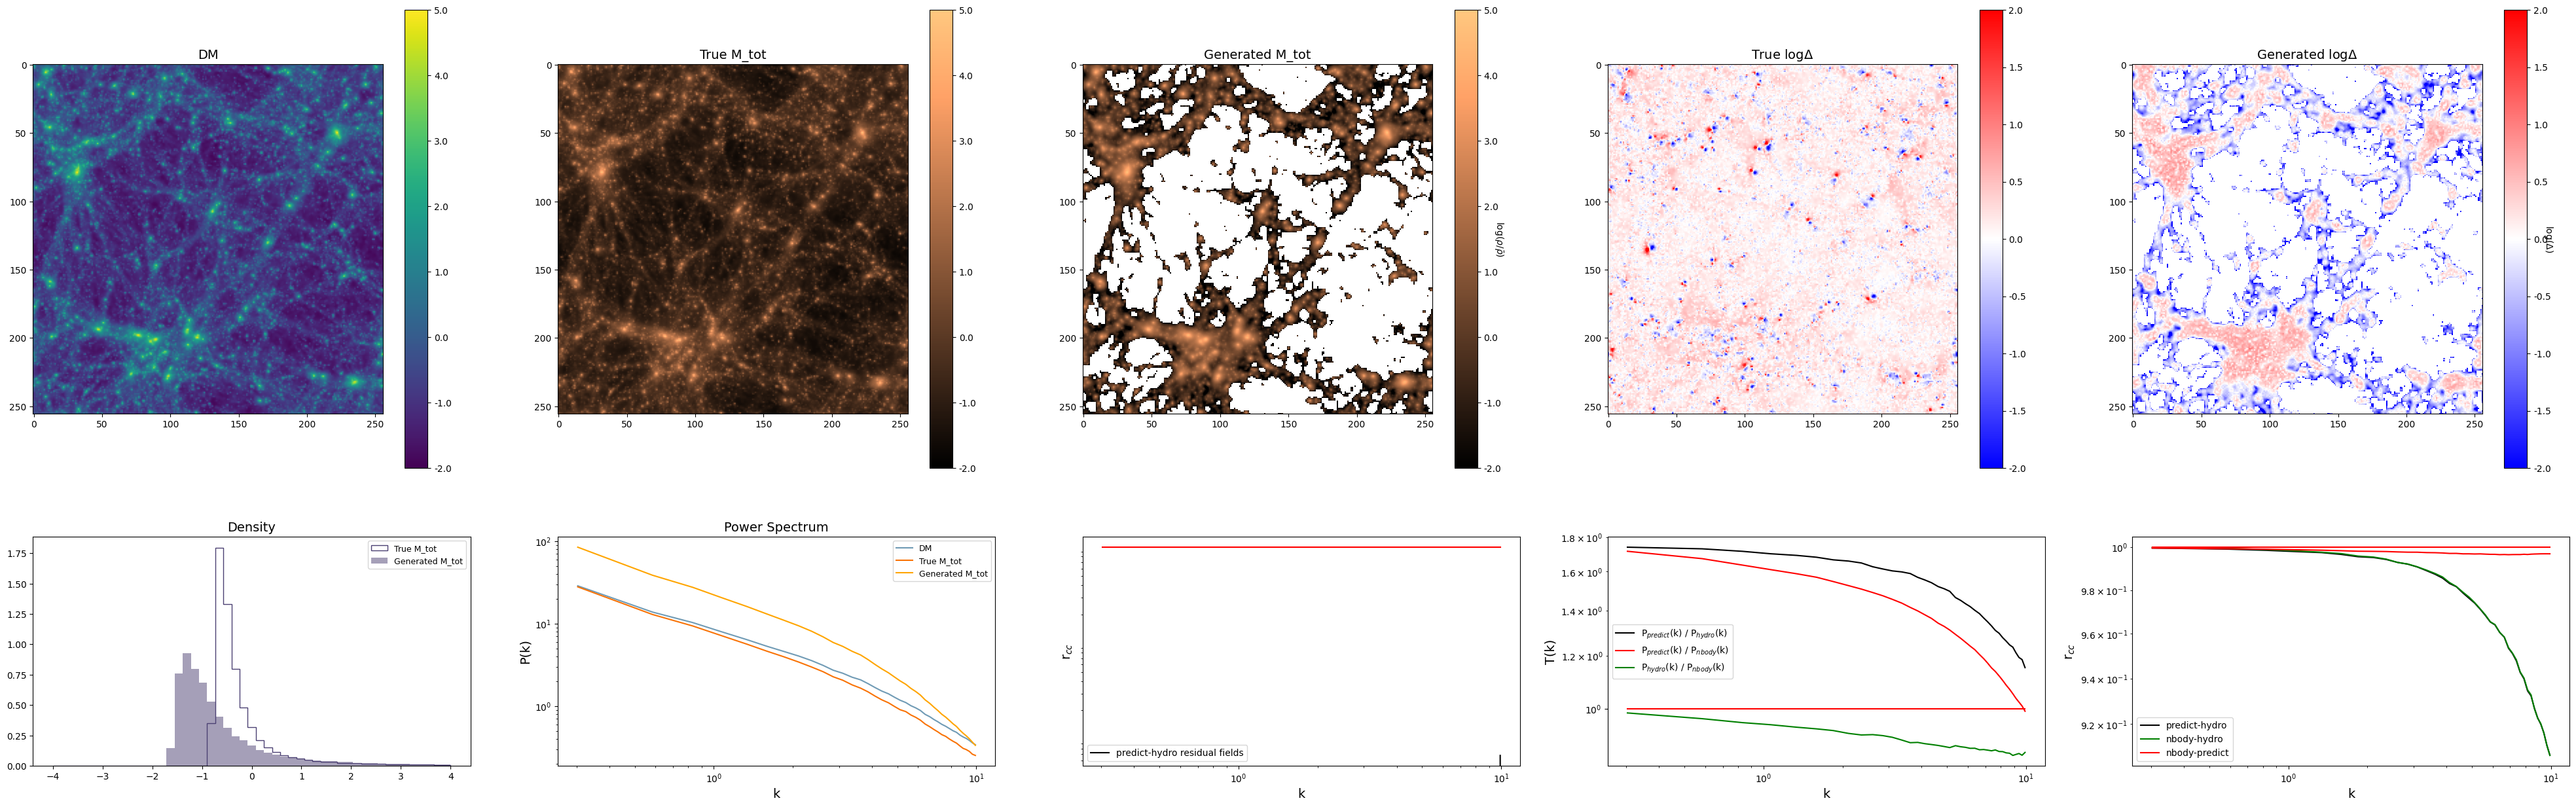

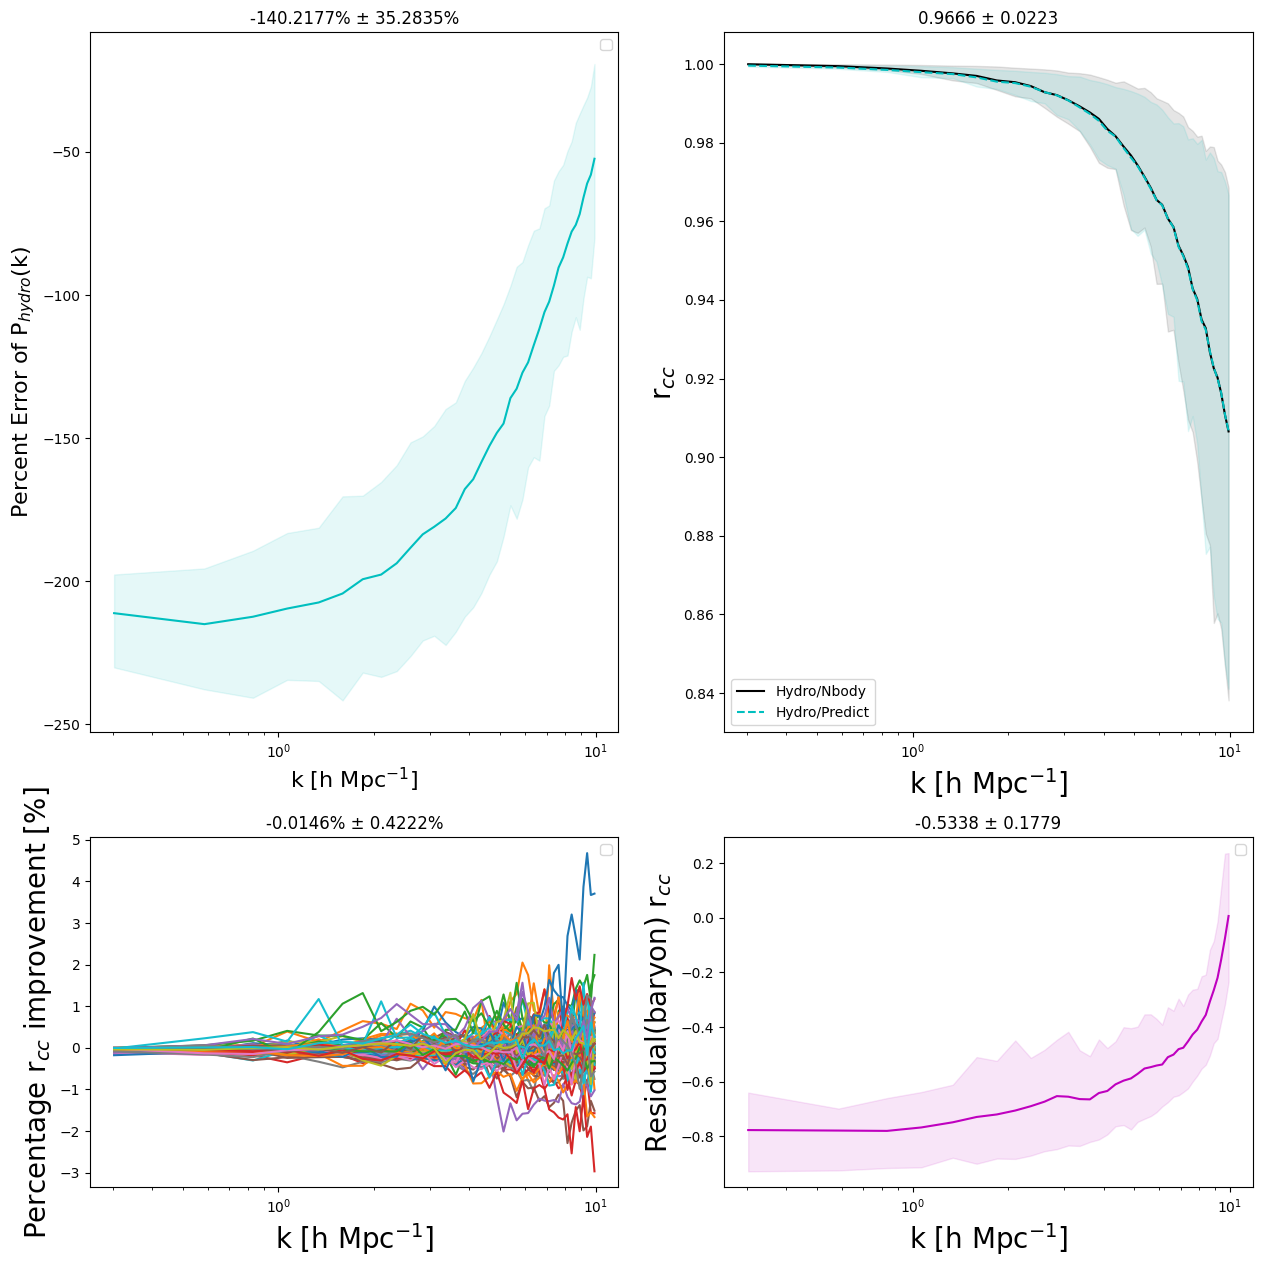

Testing DataLoader 0: 100%|██████████| 3/3 [00:32<00:00,  0.09it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         EFT_loss          │    0.3072120699473218     │
│       fourier_loss        │     4.177968574345549     │
│         l1_100rcc         │    100.29206728608494     │
│          l1_loss          │    0.2920672862250287     │
│         test_loss         │            0.0            │
│         test_rcc          │     0.963290274143219     │
└───────────────────────────┴───────────────────────────┘

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml ExistingExperiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : SIMBA_BigGANUNet2DModel_lr_tuning_warmup0.3_increasing_lrp2_epoch20_L1_EFT_loss_longer_6_20_lr_3e4_adamw_1e2_25_thickness_Nbody
COMET INFO:     url                   : https://www.comet.com/klinjin/simba/3ea041bdc3bc47f6b07433b73b274868
COMET INFO:   Metrics:
COMET INFO:     EFT_loss     : 0.3072120699473218
COMET INFO:     fourier_loss : 4.177968574345549
COMET INFO:     l1_100rcc    : 100.29206728608494
COMET INFO:     l1_loss      : 0.2920672862250287
COMET INFO:     test_l1_loss : 0.26229529097395843
COMET INFO:     test_loss    : 0.0
COMET INFO:     test_rcc     : 0.963290274143219
COMET INFO:   Others:
COMET INFO:     Created from : pyt

In [12]:
test_loss = trainer.test(model=None, datamodule=dm_25_thick_mtot, ckpt_path = path_l1)

In [ ]:
comet_logger.experiment.end()

In [12]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
print(torch.cuda.memory_summary(device='cuda:2', abbreviated=False))

In [13]:
print(torch.cuda.memory_summary(device='cuda:2', abbreviated=False))

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 2                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |